In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 50 MWp SOLAR 10-YEAR CORPORATE PPA MONTE CARLO VALUATION BENCHMARK
Contract Structure         | P50 Expected  | P90 Downside  | 95% VaR   
---------------------------------------------------------------------------
100% Merchant Exposure     | € 19.89M      | € 16.44M      | € 4.62M
Baseload Corporate PPA     | € 18.71M      | € 17.12M      | € 2.01M
Pay-as-Produced PPA        | € 23.42M      | € 22.87M      | € 0.70M


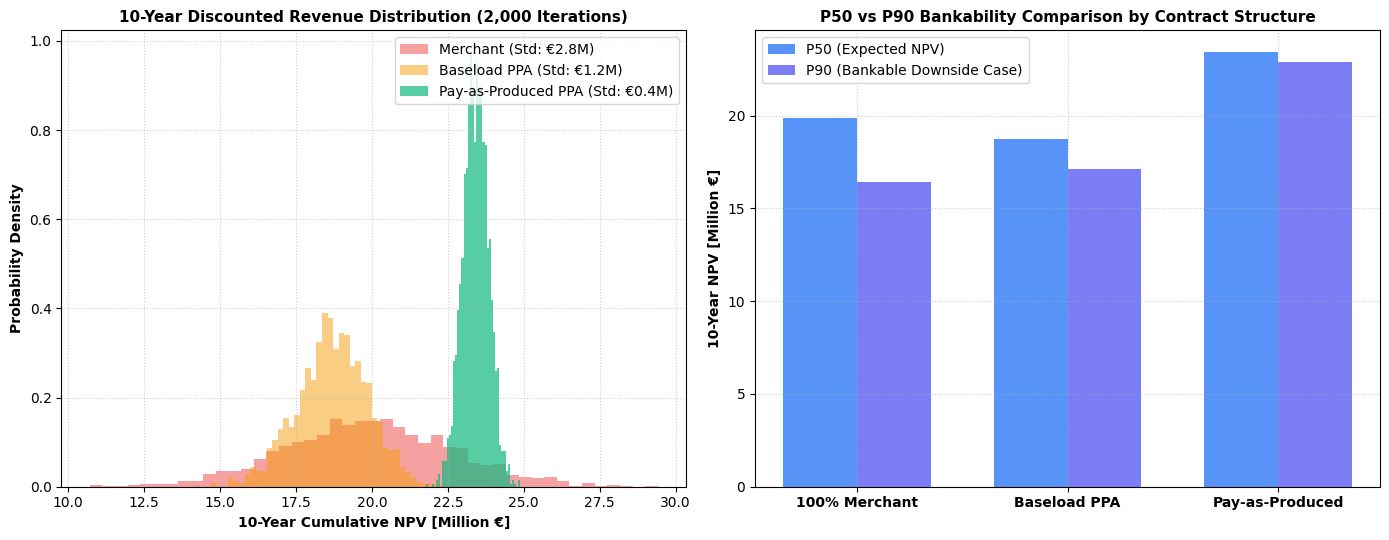

Data exported as 'ppa_monte_carlo_simulation_results_2026.csv'


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# 1. 50 MWp SOLAR PV ASSET & PPA CONTRACT SPECIFICATIONS
# ==========================================================
CAPACITY_MW = 50.0  # 50 MWp Utility Solar Farm (Germany)
SPECIFIC_YIELD_KWH_KWP = 1050.0  # kWh/kWp/year baseline
BASE_ANNUAL_GEN_MWH = CAPACITY_MW * SPECIFIC_YIELD_KWH_KWP  # 52,500 MWh/year
PPA_TENOR_YEARS = 10
N_SIMULATIONS = 2000
DISCOUNT_RATE = 0.065  # 6.5% Project WACC

# PPA Contract Pricing Parameters
PAP_STRIKE_EUR = 62.0  # Pay-as-Produced Fixed Strike Price (€/MWh)
BASELOAD_STRIKE_EUR = 68.0  # Baseload Fixed Strike Price (€/MWh)
BASELOAD_OBLIGATION_MWH_YR = 6.0 * 8760  # 52,560 MWh/year flat profile

# ==========================================================
# 2. 10-YEAR MONTE CARLO STOCHASTIC SIMULATION ENGINE
# ==========================================================
np.random.seed(42)

sim_npv_merchant = np.zeros(N_SIMULATIONS)
sim_npv_pap = np.zeros(N_SIMULATIONS)
sim_npv_baseload = np.zeros(N_SIMULATIONS)

for i in range(N_SIMULATIONS):
  annual_rev_merchant = []
  annual_rev_pap = []
  annual_rev_baseload = []

  current_base_price = 70.0  # Base wholesale price start (€/MWh)

  for yr in range(1, PPA_TENOR_YEARS + 1):
    # Stochastic Wholesale Baseload Price (Mean-reverting random walk)
    drift = 0.25 * (72.0 - current_base_price) + np.random.normal(
        0, 70.0 * 0.15
    )
    current_base_price = max(25.0, current_base_price + drift)

    # Stochastic Solar Capture Factor (Declining trajectory due to PV buildout)
    capture_factor = np.clip(
        np.random.normal(0.80 - (yr * 0.012), 0.06), 0.50, 0.95
    )
    solar_capture_price = current_base_price * capture_factor

    # Stochastic Solar Generation (P50/P90 weather variability)
    annual_gen_mwh = np.random.normal(
        BASE_ANNUAL_GEN_MWH, BASE_ANNUAL_GEN_MWH * 0.055
    )

    # 1. 100% Merchant Revenue
    rev_m = annual_gen_mwh * solar_capture_price
    annual_rev_merchant.append(rev_m)

    # 2. Pay-as-Produced (PaP) PPA Revenue
    rev_pap = annual_gen_mwh * PAP_STRIKE_EUR
    annual_rev_pap.append(rev_pap)

    # 3. Baseload PPA Revenue (with balancing risk exposure)
    contract_income = BASELOAD_OBLIGATION_MWH_YR * BASELOAD_STRIKE_EUR
    balancing_cashflow = (annual_gen_mwh * solar_capture_price) - (
        BASELOAD_OBLIGATION_MWH_YR * current_base_price
    )
    rev_bl = contract_income + balancing_cashflow
    annual_rev_baseload.append(rev_bl)

  # Discounted 10-Year NPV of Revenue Streams
  discount_factors = np.array(
      [1 / ((1 + DISCOUNT_RATE) ** yr) for yr in range(1, PPA_TENOR_YEARS + 1)]
  )

  sim_npv_merchant[i] = np.sum(np.array(annual_rev_merchant) * discount_factors)
  sim_npv_pap[i] = np.sum(np.array(annual_rev_pap) * discount_factors)
  sim_npv_baseload[i] = np.sum(np.array(annual_rev_baseload) * discount_factors)


# ==========================================================
# 3. STATISTICAL RISK METRICS (P50, P90, 95% VaR)
# ==========================================================
def get_risk_metrics(npv_array):
  p50 = np.percentile(npv_array, 50)
  p90 = np.percentile(npv_array, 10)  # Bankable downside (90% exceedance)
  var_95 = p50 - np.percentile(npv_array, 5)  # 95% Value at Risk
  std_dev = np.std(npv_array)
  return p50, p90, var_95, std_dev


p50_m, p90_m, var_m, std_m = get_risk_metrics(sim_npv_merchant)
p50_pap, p90_pap, var_pap, std_pap = get_risk_metrics(sim_npv_pap)
p50_bl, p90_bl, var_bl, std_bl = get_risk_metrics(sim_npv_baseload)

print('=' * 75)
print(' 50 MWp SOLAR 10-YEAR CORPORATE PPA MONTE CARLO VALUATION BENCHMARK')
print('=' * 75)
print(
    f"{'Contract Structure':<26} | {'P50 Expected':<13} | {'P90 Downside':<13}"
    f" | {'95% VaR':<10}"
)
print('-' * 75)
print(
    f"{'100% Merchant Exposure':<26} | €{p50_m/1e6:>6.2f}M      |"
    f' €{p90_m/1e6:>6.2f}M      | €{var_m/1e6:>5.2f}M'
)
print(
    f"{'Baseload Corporate PPA':<26} | €{p50_bl/1e6:>6.2f}M      |"
    f' €{p90_bl/1e6:>6.2f}M      | €{var_bl/1e6:>5.2f}M'
)
print(
    f"{'Pay-as-Produced PPA':<26} | €{p50_pap/1e6:>6.2f}M      |"
    f' €{p90_pap/1e6:>6.2f}M      | €{var_pap/1e6:>5.2f}M'
)
print('=' * 75)

# ==========================================================
# 4. VISUALIZATION & ASSET EXPORT
# ==========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: NPV Distribution Histogram
ax1.hist(
    sim_npv_merchant / 1e6,
    bins=45,
    density=True,
    alpha=0.5,
    color='#EF4444',
    label=f'Merchant (Std: €{std_m/1e6:.1f}M)',
)
ax1.hist(
    sim_npv_baseload / 1e6,
    bins=45,
    density=True,
    alpha=0.5,
    color='#F59E0B',
    label=f'Baseload PPA (Std: €{std_bl/1e6:.1f}M)',
)
ax1.hist(
    sim_npv_pap / 1e6,
    bins=45,
    density=True,
    alpha=0.7,
    color='#10B981',
    label=f'Pay-as-Produced PPA (Std: €{std_pap/1e6:.1f}M)',
)
ax1.set_title(
    '10-Year Discounted Revenue Distribution (2,000 Iterations)',
    fontweight='bold',
    fontsize=11,
)
ax1.set_xlabel('10-Year Cumulative NPV [Million €]', fontweight='bold')
ax1.set_ylabel('Probability Density', fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

# Plot 2: P50 vs P90 Bankability Comparison
structures = ['100% Merchant', 'Baseload PPA', 'Pay-as-Produced']
p50_vals = [p50_m / 1e6, p50_bl / 1e6, p50_pap / 1e6]
p90_vals = [p90_m / 1e6, p90_bl / 1e6, p90_pap / 1e6]
x = np.arange(len(structures))
width = 0.35

ax2.bar(
    x - width / 2,
    p50_vals,
    width,
    label='P50 (Expected NPV)',
    color='#3B82F6',
    alpha=0.85,
)
ax2.bar(
    x + width / 2,
    p90_vals,
    width,
    label='P90 (Bankable Downside Case)',
    color='#6366F1',
    alpha=0.85,
)
ax2.set_ylabel('10-Year NPV [Million €]', fontweight='bold')
ax2.set_title(
    'P50 vs P90 Bankability Comparison by Contract Structure',
    fontweight='bold',
    fontsize=11,
)
ax2.set_xticks(x)
ax2.set_xticklabels(structures, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig('corporate_ppa_monte_carlo_valuation.png', dpi=300)
plt.show()

# Export Simulation Dataset
df_sim_export = pd.DataFrame({
    'sim_id': np.arange(1, N_SIMULATIONS + 1),
    'npv_merchant_eur': np.round(sim_npv_merchant, 2),
    'npv_pay_as_produced_eur': np.round(sim_npv_pap, 2),
    'npv_baseload_eur': np.round(sim_npv_baseload, 2),
})
df_sim_export.to_csv('ppa_monte_carlo_simulation_results_2026.csv', index=False)
print("Data exported as 'ppa_monte_carlo_simulation_results_2026.csv'")